## Database Indexes
A database index is a super-efficient lookup table that allows a database to find data much faster.
It holds the indexed column values along with pointers to the corresponding rows in the table.

Here's a step-by-step explanation of how database indexes work:

1. Index Creation: The database administrator creates an index on a specific column or set of columns.
2. Index Building: The database management system builds the index by scanning the table and storing the values of the indexed column(s) along with a pointer to the corresponding data.
3. Query Execution: When a query is executed, the database engine checks if an index exists for the requested column(s).
4. Index Search: If an index exists, the database searches the index for the requested data, using the pointers to quickly locate the data.
5. Data Retrieval: The database retrieves the requested data, using the pointers from the index.


### Benefits of Database Indexes
Database indexes offer several benefits, including:
1. Faster Query Performance
2. Reduced CPU Usage
3. Rapid Data Retrieval
4. Efficient Sorting: Indexes can also be used to efficiently sort data based on the indexed columns, eliminating the need for expensive sorting operations.
5. Better Data Organization: Indexes can help maintain data organization and structure, making it easier to manage and maintain the database.

### Types of Database Indexes
#### Indexes based on Structure and Key Attributes:
1. Primary Index: Automatically created when a primary key constraint is defined on a table. Ensures uniqueness and helps with super-fast lookups using the primary key.

2. Clustered Index: Determines the order in which data is physically stored in the table. A clustered index is most useful when we’re searching in a range. Only one clustered index can exist per table.

3. Non-clustered or Secondary Index: This index does not store data in the order of the index. Instead, it provides a list of virtual pointers or references to the location where the data is actually stored.

#### Indexes based on Data Coverage:
1. Dense index: Has an entry for every search key value in the table. Suitable for situations where the data has a small number of distinct search key values or when fast access to individual records is required.

2. Sparse index: Has entries only for some of the search key values. Suitable for situations where the data has a large number of distinct search key values.

### Specialized Index Types:
1. Bitmap Index: Excellent for columns with low cardinality (few distinct values). Common in data warehousing.

2. Hash Index: A index that uses a hash function to map values to specific locations. Great for exact match queries.

3. Filtered Index: Indexes a subset of rows based on a specific filter condition. Useful to improve query speed on commonly filtered columns.

4. Covering Index: Includes all the columns required by a query in the index itself, eliminating the need to access the underlying table data. Makes read-heavy queries significantly faster.

5. Function-based index: Indexes that are created based on the result of a function or expression applied to one or more columns of a table.

6. Full-Text Index: A index designed for full-text search, allowing for efficient searching of text data.

7. Spatial Index: Used for indexing geographical data types.

8. Composite Index: An index on multiple columns together. The index is most useful when queries filter on the leftmost prefix columns first. Rule of thumb: Put high-cardinality, most-selective, and most-frequently-filtered columns first.

### Different types of Indexes
Commonly Used data structures that powers the indexes:

#### B-Tree(Balanced Tree):
B-Trees have a hierarchical structure with a root node, internal nodes (index nodes), and leaf nodes. Each node in a B-Tree contains a sorted array of keys and pointers to child nodes.

They are so well-suited:
1. Self-Balancing: B-trees ensure that the 'height' of the tree stays balanced even when inserting or deleting data. This ensures logarithmic time complexity for insertion, deletion, and searching.

2. Ordered: B-trees keep the data sorted, making range queries ("find all orders between date X and Y") and inequality comparisons very fast. Supports equality (=) and range (<, >, BETWEEN, ORDER BY) queries.

3. Disk-Friendly: B-trees are designed to work well with disk-based storage. A single node of a B-tree often corresponds to a disk block, minimizing disk access operations.

=> Databases used: PostgreSQL, MySQL (InnoDB), MongoDB.

=> When to use: Almost always — primary keys, foreign keys, range queries.

=> Cost: Extra disk space + write overhead (tree must rebalance on insert/update/delete).

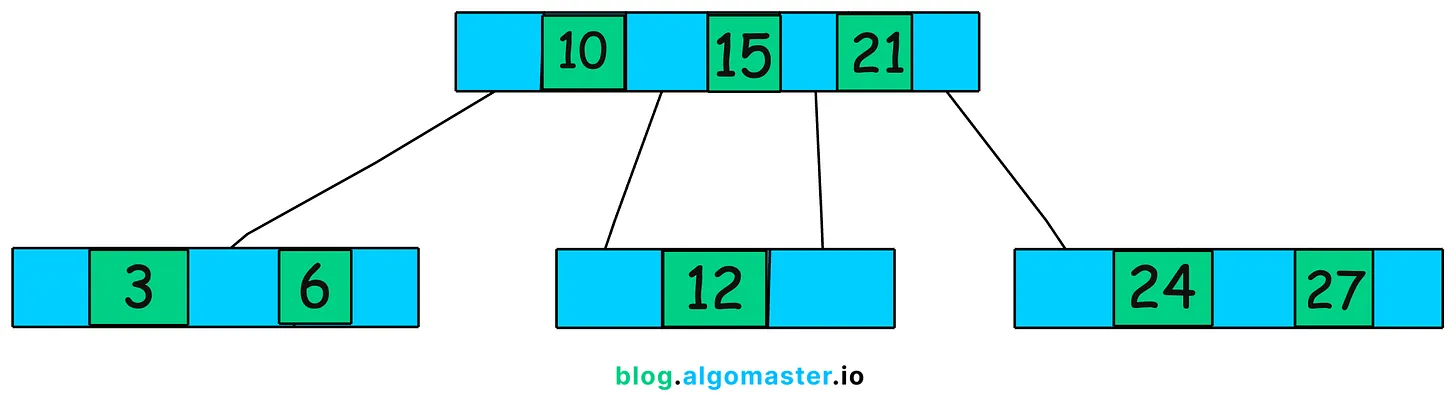

#### B+ tree:
In a B+ tree, all data values are stored only in the leaf nodes, and leaf nodes are linked in a doubly-linked list, which can further improve performance for certain use cases like range queries.

=> Databases used: PostgreSQL, MySQL (InnoDB)

=> When to use: Pure key-value lookups (e.g., user ID → user row, session token lookup).

#### Hash Index
Hash tables are used for hash indexes, which are based on a hash function. A hash table consists of an array of buckets, with each bucket containing the addresses for rows in the data.

Hash indexes employ a hash function to map keys to their corresponding bucket in the hash table, enabling constant-time lookup operations.Hash indexes provide fast equality lookups, as the hash function determines the exact location of the data based on the key.

However, hash indexes do not support range queries or sorting efficiently.

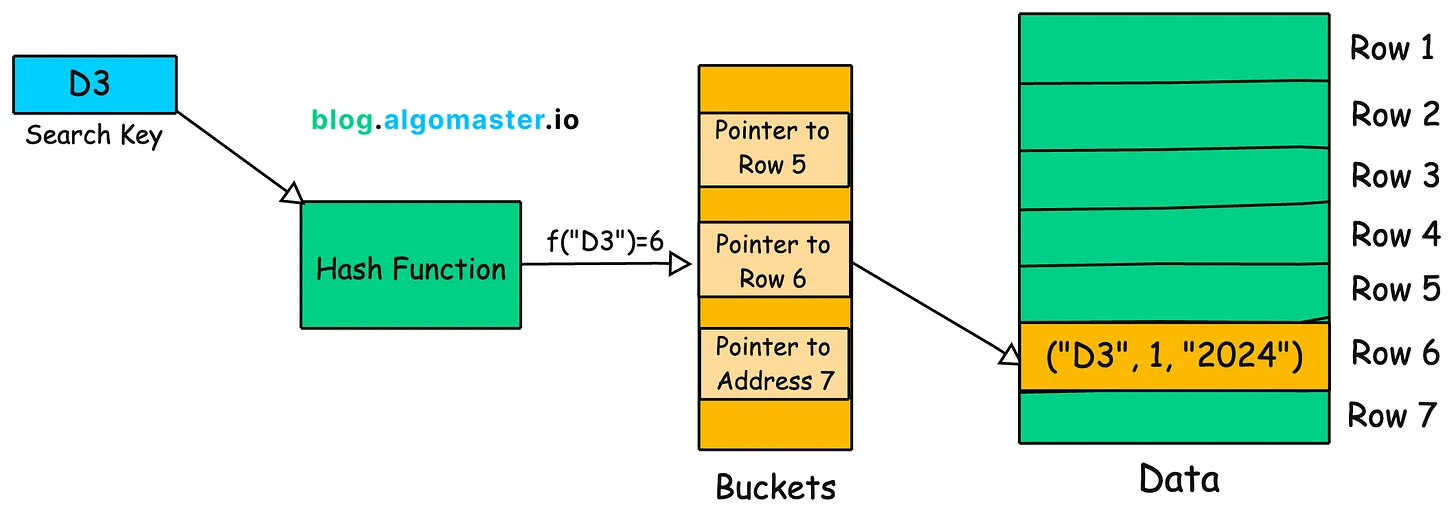

#### LSM Tree (Log-Structured Merge Tree)
Designed for write-heavy workloads. Instead of updating in place, all writes go to an in-memory buffer (MemTable) then are flushed sequentially to disk as immutable SSTables.
1. Writes are always sequential (fast).
2. Reads are slower — must merge across multiple SSTables.
3. Background compaction merges SSTables to reclaim space.

=> Databases Used by: Cassandra, RocksDB, LevelDB, HBase, ScyllaDB.
 
=> When to use: High-volume time-series, metrics, logs, event streams (millions of writes/sec).

=> Trade-off: Write amplification during compaction; reads require checking multiple levels.

LSM Wins when:
1. Your disk throughput matters more than disk wear (SSDs handle amplification better than HDDs)
2. You have far more writes than reads (Cassandra time-series, Kafka offsets, metrics)
3. You can tune compaction strategy to match your workload (size-tiered vs leveled)

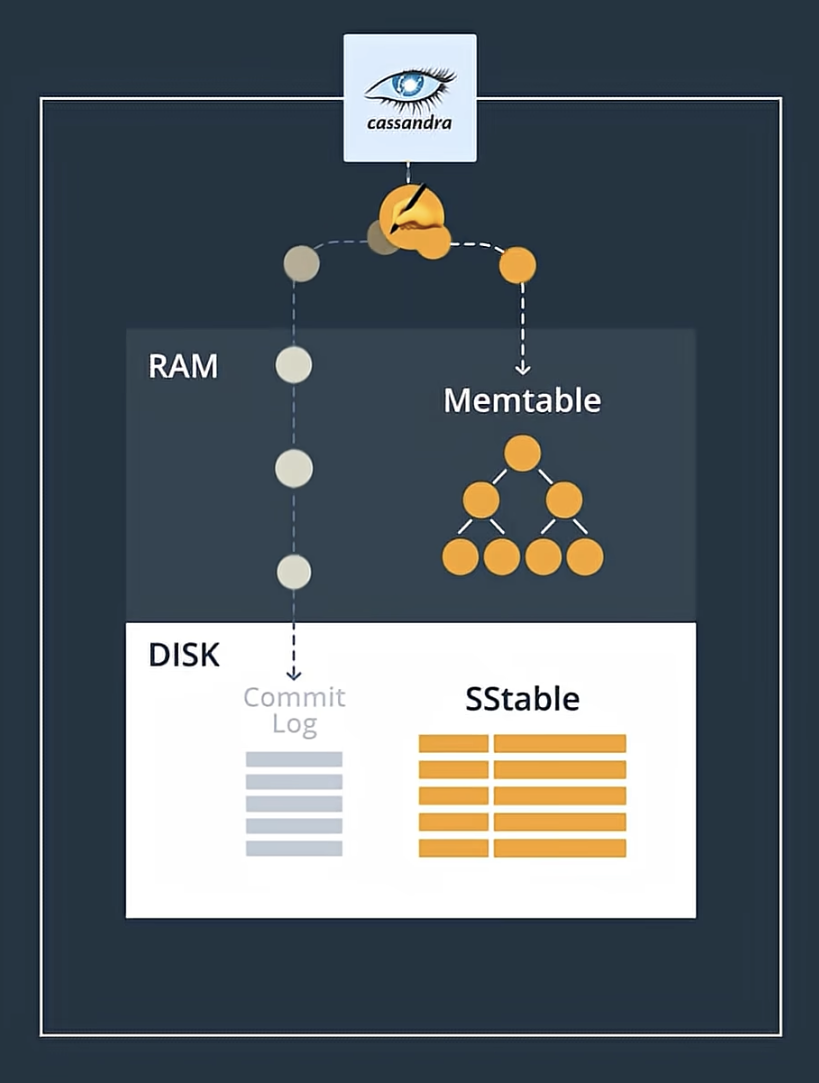

#### Inverted Index
Core of full-text search engines. Maps each word → list of documents containing it.Supports keyword search, phrase matching, ranked results.

=> When to use: Search bars, document search, e-commerce product search, log analysis.

=> Databases Used by: Elasticsearch, Solr, PostgreSQL tsvector, Lucene.

=> Cost: Expensive to build and update; tokenization/stemming adds preprocessing overhead.

#### Geospatial Index
Specialized indexes for latitude/longitude and polygon queries (NEARBY, WITHIN, INTERSECTS).

=> Databases Used by: Used by: PostGIS (PostgreSQL extension), MongoDB (2dsphere index), Redis (GEOADD/GEORADIUS).

=> When to use: Ride-sharing (find nearby drivers), delivery apps (restaurants in radius), maps.

#### Bitmaps
Each bit in the bitmap corresponds to a row, and the value of the bit indicates whether the key value exists in that row. Bitmap indexes use a bitmap (a binary array) to represent the presence or absence of a specific key value in each row of a table.

Bitmap indexes are well-suited for columns with low cardinality (a small number of distinct values) and for performing complex queries involving multiple conditions.
Bitmap operations like AND, OR, and NOT are performed efficiently using bitwise operations, making bitmap indexes suitable for analytical queries involving multiple columns.

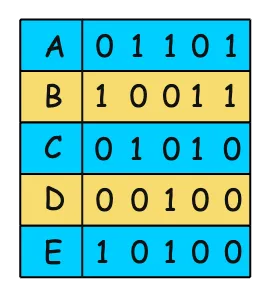

### How to use Database Indexes Smartly
To get the most out of database indexes, consider these best practices:

1. Identify Query Patterns: Analyze the most frequent and critical queries executed against your database to determine which columns to index and which type of index to use.

2. Index Frequently Used Columns: Consider indexing columns that are frequently used in WHERE, JOIN, and ORDER BY clauses.

3. Index Selective Columns: Indexes are most effective on columns with a good spread of data values (high cardinality). Indexing a gender column might be less beneficial than one with a unique customer_id.

4. Use Appropriate Index Types: Choose the right index type for your data and queries.

5. Consider Composite Indexes: For queries involving multiple columns, consider creating composite indexes that encompass all relevant columns. This reduces the need for multiple single-column indexes and improves query performance.

6. Monitor Index Performance: Regularly monitor index performance, remove unused indexes and adjust your indexing strategy as the database workload evolves.

7. Avoid Over-Indexing: Avoid creating too many indexes, as this can lead to increased storage requirements and slower write performance.

8. Indexes take up extra disk space since they're additional data structures that need to be stored alongside your tables.

9. Every time you insert, update, or delete data in a table with an index, the index needs to update too. This can slightly slow down write operations.

To summarize, indexes are a powerful tool to optimize database query performance.




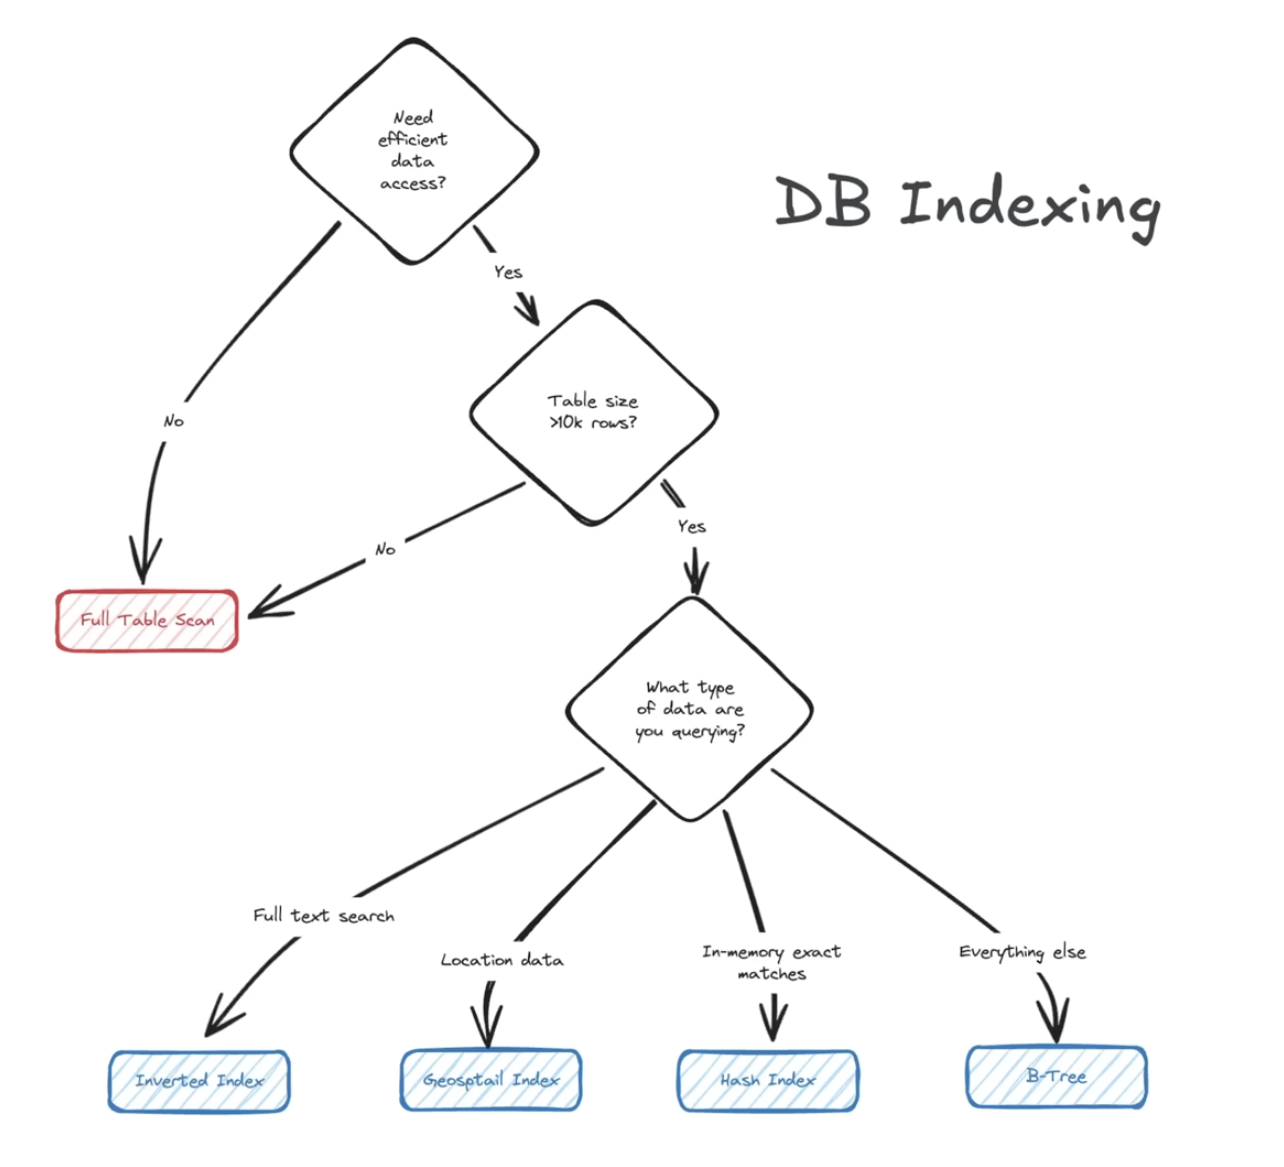